In [16]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from pic0rick import device

In [3]:
p = device.Pic0rick()

Device on /dev/ttyACM0


In [6]:
p.version()

{'raw': 'version\r\npic0rick firmware v0.1.1\r\nchanges: `version` command now also reports board/chip, MUX state, the git build hash (with -dirty) and the GitHub release URL. CI release notes list both firmware and python library versions.\r\nboard:   pico2 (RP2350)\r\nmux:     enabled (MAX14866)\r\nbuild:   b0d9435-dirty\r\nrelease: https://github.com/kelu124/pic0rick/releases/tag/fw-v0.1.1\r\nrun> ',
 'version': '0.1.1',
 'changes': '`version` command now also reports board/chip, MUX state, the git build hash (with -dirty) and the GitHub release URL. CI release notes list both firmware and python library versions.',
 'board': 'pico2',
 'chip': 'RP2350',
 'mux': 'enabled (MAX14866)',
 'mux_enabled': True,
 'build': 'b0d9435-dirty',
 'release': 'https://github.com/kelu124/pic0rick/releases/tag/fw-v0.1.1'}

In [4]:
p.pulse_adc_trigger(pon = 200,poff=200,damp=2000)

[b'start acq 200 200 2000\r\n',
 b'Acquisition of 8000 samples started\r\n',
 b'ADC timeout occured\r\n',
 b'Acquisition ended\r\n',
 b'run> ',
 b'']

In [11]:
def hex_to_uint(hex_str: str) -> int:
    """Decode a hexadecimal string (e.g. '1F5' or '0x1F5') into an unsigned int."""
    value = int(hex_str, 16)
    if value < 0:
        raise ValueError("Unsigned integers cannot be negative")
    return value

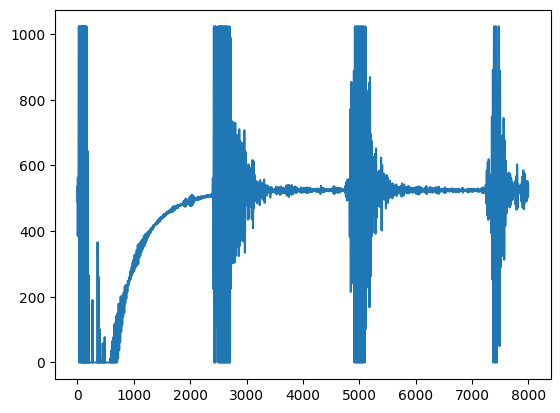

In [17]:
signal = [hex_to_uint(x) for x in p.read()[2].decode().strip().split(",") if len(x)]
plt.plot(signal)